In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Question: Is the average Goals/xG ratio different from 1.0?
# Secondary: Does this differ between forwards and midfielders?
# Data: FIFA World Cup 2026 Attacking stats, manually copied and parsed in Python.

np.random.seed(42)

# Load the raw dataset
df = pd.read_csv("fifa_attacking_stats_real.csv")
print("Loaded! Shape:", df.shape)
display(df.head(10))

Loaded! Shape: (100, 14)


,Rank,player_name,nation,position,Assists,Attempts On Target,Attempts At Goal,Attempts At Goal Conv. Rate (%),Attempts Inside the Penalty Area,Attempts Outside the Penalty Area,Headed Attempts at Goal,xG,xG Efficiency,Corners
0,1,Michael Olise,FRA,FW,7,5,20,0.0,10,10,0,2.34,0x,25
1,2,Martin Odegaard,NOR,MF,4,3,9,0.0,5,4,0,0.72,0x,12
2,2,Kylian Mbappe,FRA,FW,4,23,41,24.0,27,14,0,6.54,1.53x,5
3,2,Brahim Diaz,MAR,FW,4,1,6,0.0,4,2,0,0.31,0x,1
4,2,Bruno Guimaraes,BRA,MF,4,2,8,0.0,5,3,1,1.02,0x,8
5,2,Lionel Messi,ARG,FW,4,19,35,23.0,16,19,0,6.18,1.29x,38
6,7,Roberto Alvarado,MEX,FW,3,0,5,0.0,2,3,0,0.28,0x,14
7,7,Anthony Gordon,ENG,FW,3,4,6,17.0,6,0,2,0.70,1.43x,0
8,7,Florian Wirtz,GER,MF,3,1,10,0.0,5,5,0,0.97,0x,5
9,7,Andreas Schjelderup,NOR,MF,3,2,3,33.0,3,0,0,0.20,5.12x,0


In [2]:
# Convert xG Efficiency text (e.g. "1.53x") into a numeric ratio
df['goal_xg_ratio'] = df['xG Efficiency'].str.replace('x', '', regex=False).astype(float)

# Exclude players with xG = 0 (ratio undefined without any shot quality)
df_clean_xg = df[df['xG'] > 0].copy()

# Save the cleaned dataset
df_clean_xg.to_csv("fifa_attacking_stats_cleaned.csv", index=False)

print("Population size:", len(df_clean_xg))
print("Population mean Goals/xG ratio:", round(df_clean_xg['goal_xg_ratio'].mean(), 3))

Population size: 88
Population mean Goals/xG ratio: 1.329


In [3]:
# Take a random sample, n = 30, fixed seed for reproducibility
RANDOM_STATE = 42
sample_xg = df_clean_xg.sample(n=30, random_state=RANDOM_STATE)

print("Sample size:", len(sample_xg))
display(sample_xg[['player_name', 'position', 'xG', 'goal_xg_ratio']].head(10))

Sample size: 30


,player_name,position,xG,goal_xg_ratio
84,Baris Alper Yilmaz,FW,0.06,16.87
0,Michael Olise,FW,2.34,0.00
26,Ousmane Dembele,FW,2.10,2.86
22,Leandro Trossard,FW,1.67,1.20
12,Chris Wood,FW,0.47,0.00
74,Kaishu Sano,MF,0.09,11.52
10,Bukayo Saka,FW,1.72,1.74
18,Nicolas Raskin,MF,0.13,0.00
4,Bruno Guimaraes,MF,1.02,0.00
75,Lee Kangin,MF,0.15,0.00


In [4]:
def calculate_descriptive_stats(data_series, group_name):
    """
    Manually calculates and prints basic descriptive statistics for a pandas Series.
    """
    count = len(data_series)
    mean = data_series.mean()
    std_dev = data_series.std()
    minimum = data_series.min()
    median = data_series.median()
    maximum = data_series.max()

    q1 = np.percentile(data_series, 25)
    q3 = np.percentile(data_series, 75)

    print(f"--- Descriptive Statistics for {group_name} ---")
    print(f"Count (n): {count}")
    print(f"Mean:      {mean:.3f}")
    print(f"Std Dev:   {std_dev:.3f}")
    print(f"Minimum:   {minimum:.3f}")
    print(f"25th %ile: {q1:.3f}")
    print(f"Median:    {median:.3f}")
    print(f"75th %ile: {q3:.3f}")
    print(f"Maximum:   {maximum:.3f}")
    print(f"Skewness:  {data_series.skew():.3f}\n")

calculate_descriptive_stats(sample_xg['goal_xg_ratio'], "Goals/xG Ratio Sample")

--- Descriptive Statistics for Goals/xG Ratio Sample ---
Count (n): 30
Mean:      2.171
Std Dev:   3.728
Minimum:   0.000
25th %ile: 0.000
Median:    1.045
75th %ile: 2.660
Maximum:   16.870
Skewness:  2.799



In [5]:
# 95% Confidence Interval for the population mean
def get_95_ci(data):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    ci = stats.t.interval(0.95, n - 1, loc=mean, scale=se)
    return ci

ci_xg = get_95_ci(sample_xg['goal_xg_ratio'])
print(f"95% CI: ({ci_xg[0]:.3f}, {ci_xg[1]:.3f})")

95% CI: (0.779, 3.563)


In [6]:
# One-sample t-test: is the mean ratio different from 1.0?
# H0: mean ratio = 1.0   H1: mean ratio != 1.0
# Reuses the same sample as the CI above.

t_stat_xg, p_value_xg = stats.ttest_1samp(sample_xg['goal_xg_ratio'], popmean=1.0)

print("=== One-Sample t-Test Results ===")
print(f"t-statistic: {t_stat_xg:.4f}")
print(f"p-value:     {p_value_xg:.4f}")
print("Decision:", "Reject H0" if p_value_xg < 0.05 else "Fail to reject H0")

=== One-Sample t-Test Results ===
t-statistic: 1.7210
p-value:     0.0959
Decision: Fail to reject H0


In [7]:
# Two-sample t-test: FW vs MF (needs two separate samples, unlike the one-sample test)
# H0: mean ratio (FW) = mean ratio (MF)   H1: mean ratio (FW) != mean ratio (MF)

fw_pop_xg = df_clean_xg[df_clean_xg['position'] == 'FW']['goal_xg_ratio']
mf_pop_xg = df_clean_xg[df_clean_xg['position'] == 'MF']['goal_xg_ratio']

n_fw, n_mf = min(20, len(fw_pop_xg)), min(15, len(mf_pop_xg))
fw_sample_xg = fw_pop_xg.sample(n=n_fw, random_state=RANDOM_STATE)
mf_sample_xg = mf_pop_xg.sample(n=n_mf, random_state=RANDOM_STATE)

# Check equal-variance assumption first
levene_stat, levene_p = stats.levene(fw_sample_xg, mf_sample_xg)
equal_var = levene_p > 0.05
print(f"Levene p={levene_p:.4f} -> equal_var={equal_var}")

t_stat3, p_value3 = stats.ttest_ind(fw_sample_xg, mf_sample_xg, equal_var=equal_var)

print("\n=== Two-Sample t-Test Results ===")
print(f"FW mean: {fw_sample_xg.mean():.3f}   MF mean: {mf_sample_xg.mean():.3f}")
print(f"t-statistic: {t_stat3:.4f}")
print(f"p-value:     {p_value3:.4f}")
print("Decision:", "Reject H0" if p_value3 < 0.05 else "Fail to reject H0")

Levene p=0.5972 -> equal_var=True

=== Two-Sample t-Test Results ===
FW mean: 1.804   MF mean: 2.137
t-statistic: -0.2795
p-value:     0.7816
Decision: Fail to reject H0


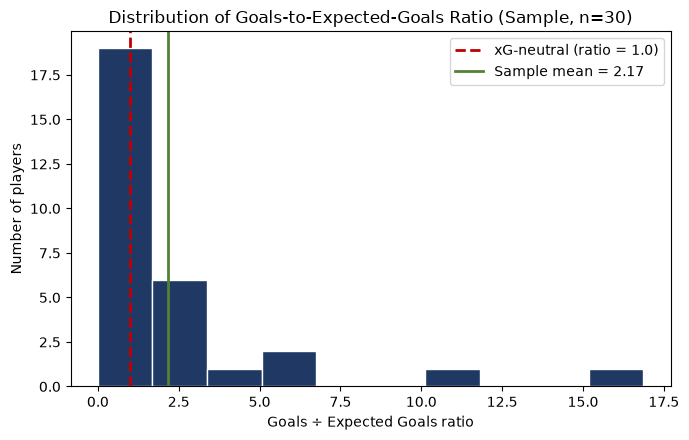

In [8]:
# Chart: distribution of the sample's Goals/xG ratio
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sample_xg['goal_xg_ratio'], bins=10, color='#1F3864', edgecolor='white')
ax.axvline(1.0, color='#C00000', linestyle='--', linewidth=2, label='xG-neutral (ratio = 1.0)')
ax.axvline(sample_xg['goal_xg_ratio'].mean(), color='#548235', linestyle='-', linewidth=2,
           label=f"Sample mean = {sample_xg['goal_xg_ratio'].mean():.2f}")
ax.set_xlabel('Goals ÷ Expected Goals ratio')
ax.set_ylabel('Number of players')
ax.set_title('Distribution of Goals-to-Expected-Goals Ratio (Sample, n=30)')
ax.legend()
plt.tight_layout()
plt.savefig('xg_ratio_distribution.png', dpi=150)
plt.show()

# Conclusion:
# - One-sample t-test: fail to reject H0 -- no evidence players over/under-performed as a group
# - Two-sample t-test: fail to reject H0 -- no significant difference between FW and MF
# - Distribution is right-skewed: most players near 0, a few big outperformers
# - Limitation: population = FIFA's Attacking leaderboard (>=1 assist), not every player